# Demo. Test Two Patch Lattice Surgery

In [7]:
import sys
from pathlib import Path

ROOT = Path('../..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import stim

from lightstim.qec_code.surface_code.unrotated import (
    UnrotatedSurfaceCode,
    UnrotatedSurfaceCodeExtractionBlock,
    UnrotatedTwoPatchCoupler,
)
from lightstim.protocols.two_patch_ls import TwoPatchLSExperiment

## Two Patch LS. Unrotated Surface Code

For XX/ZZ measurement experiments, the initialization basis and the measurement basis are the same.  
For teleportation experiments (Patch 1 -> Patch 2), the measurement basis can be different from the initialization basis. The protocol is:  
(1) Patch 2 in $|+\rangle$ -> ZZ measurement + X measurement on Patch 1;  
(2) Patch 2 in $|0\rangle$ -> XX measurement + Z measurement on Patch 1; 
The measurement basis on Patch 2 is the same as the initialization basis on Patch 1, because we wanna verify if the state on Patch 1 has been teleported to Patch 2.

## Example 1: XX Measurement on $|++\rangle$, $|+0\rangle$, $|0+\rangle$, $|00\rangle$

Two logical observables for $|++\rangle$. One logical observables for the rest because the XX measurement result is random. We may want adjust the rotation for different visualizations. But it should work regardless of rotation because our algorithm is robust.

Creating patches...
Rotating patch1 by pi...
Setting up QEC system...
Registering coupler with interaction type XX...
Writing coordinates...
Initializing code patch data qubits...
Building 2 rounds of syndrome extraction (before coupler activation)...
Activating the coupler...
Initializing coupler data qubits...
Building 2 rounds of syndrome extraction (after coupler activation)...
Measuring data qubits...
Number of logical observables:  1


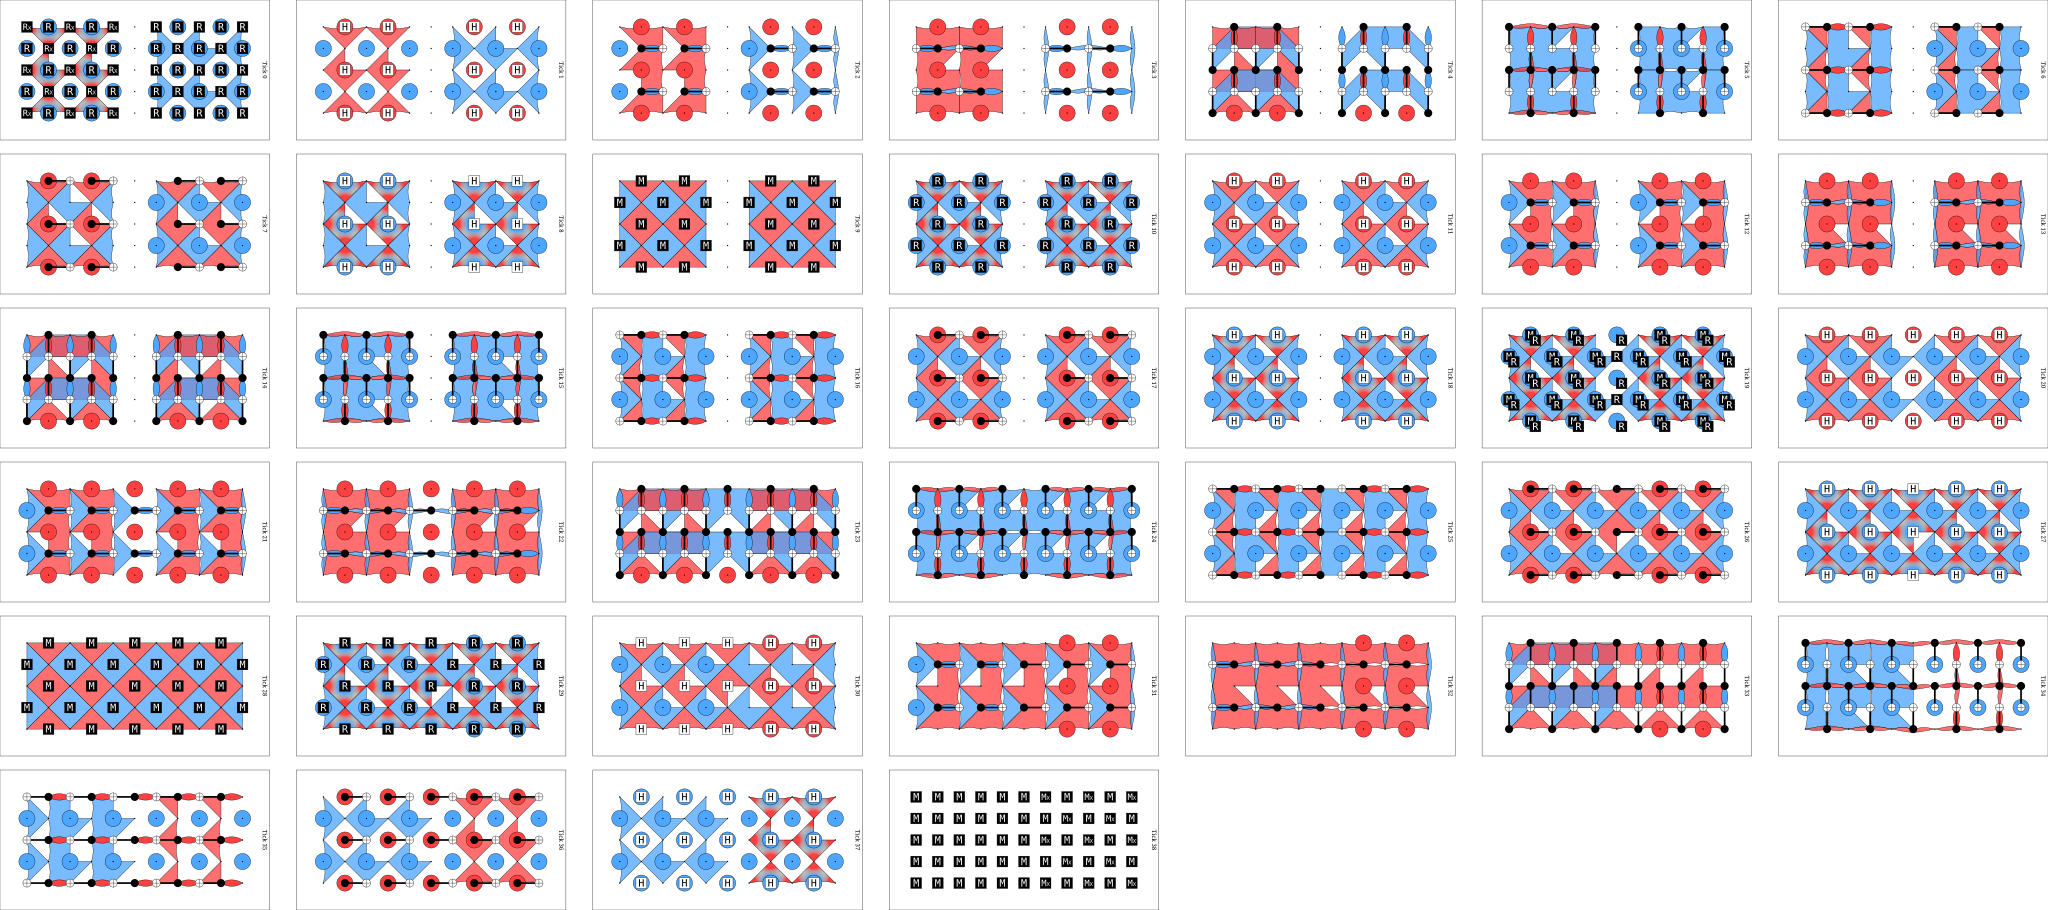

In [8]:
# Example 1: Basic two-patch LS with default settings
experiment_xx = TwoPatchLSExperiment(
    patch1_config={"distance": 3},
    patch2_config={"distance": 3},
    offset=(6, 0),
    interaction_type="XX",
    initial_state_patch1="X", # "X", "Z"
    initial_state_patch2="Z", # "X", "Z"
    measure_state_patch1="Z",
    measure_state_patch2="X",
    rounds=2
    # rotate_patch1=False
    # We may want adjust the rotation for different visualizations
)

circuit = experiment_xx.build()
print("Number of logical observables: ", circuit.num_observables)
# circuit.diagram("detslice-with-ops-svg")
circuit.diagram("detslice-with-ops-svg") # "L1"

## Example 2: ZZ Measurement on $|00\rangle$, $|0+\rangle$, $|+0\rangle$, $|++\rangle$

In [9]:
# Example 2: ZZ interaction with different initial states
experiment_zz = TwoPatchLSExperiment(
    patch1_config={"distance": 3},
    patch2_config={"distance": 3},
    offset=(0, 6),
    interaction_type="ZZ",
    initial_state_patch1="Z", # "X", "Z"
    initial_state_patch2="Z", # "X", "Z"
    measure_state_patch1="Z",
    measure_state_patch2="Z",
    rounds=2
)

circuit_zz = experiment_zz.build()
# circuit_zz.diagram("detslice-with-ops-svg")
# circuit_zz.diagram("detslice-with-ops-svg", filter_coords=["L0"]) # "L1"

Creating patches...
Rotating patch1 by pi...
Setting up QEC system...
Registering coupler with interaction type ZZ...
Writing coordinates...
Initializing code patch data qubits...
Building 2 rounds of syndrome extraction (before coupler activation)...
Activating the coupler...
Initializing coupler data qubits...
Building 2 rounds of syndrome extraction (after coupler activation)...
Measuring data qubits...


## Example 3: Rectangular Patches with Different Sizes, XX Measurment on $|++\rangle$

Creating patches...
Rotating patch1 by pi...
Setting up QEC system...
Registering coupler with interaction type XX...
Writing coordinates...
Initializing code patch data qubits...
Building 2 rounds of syndrome extraction (before coupler activation)...
Activating the coupler...
Initializing coupler data qubits...
Building 2 rounds of syndrome extraction (after coupler activation)...
Measuring data qubits...


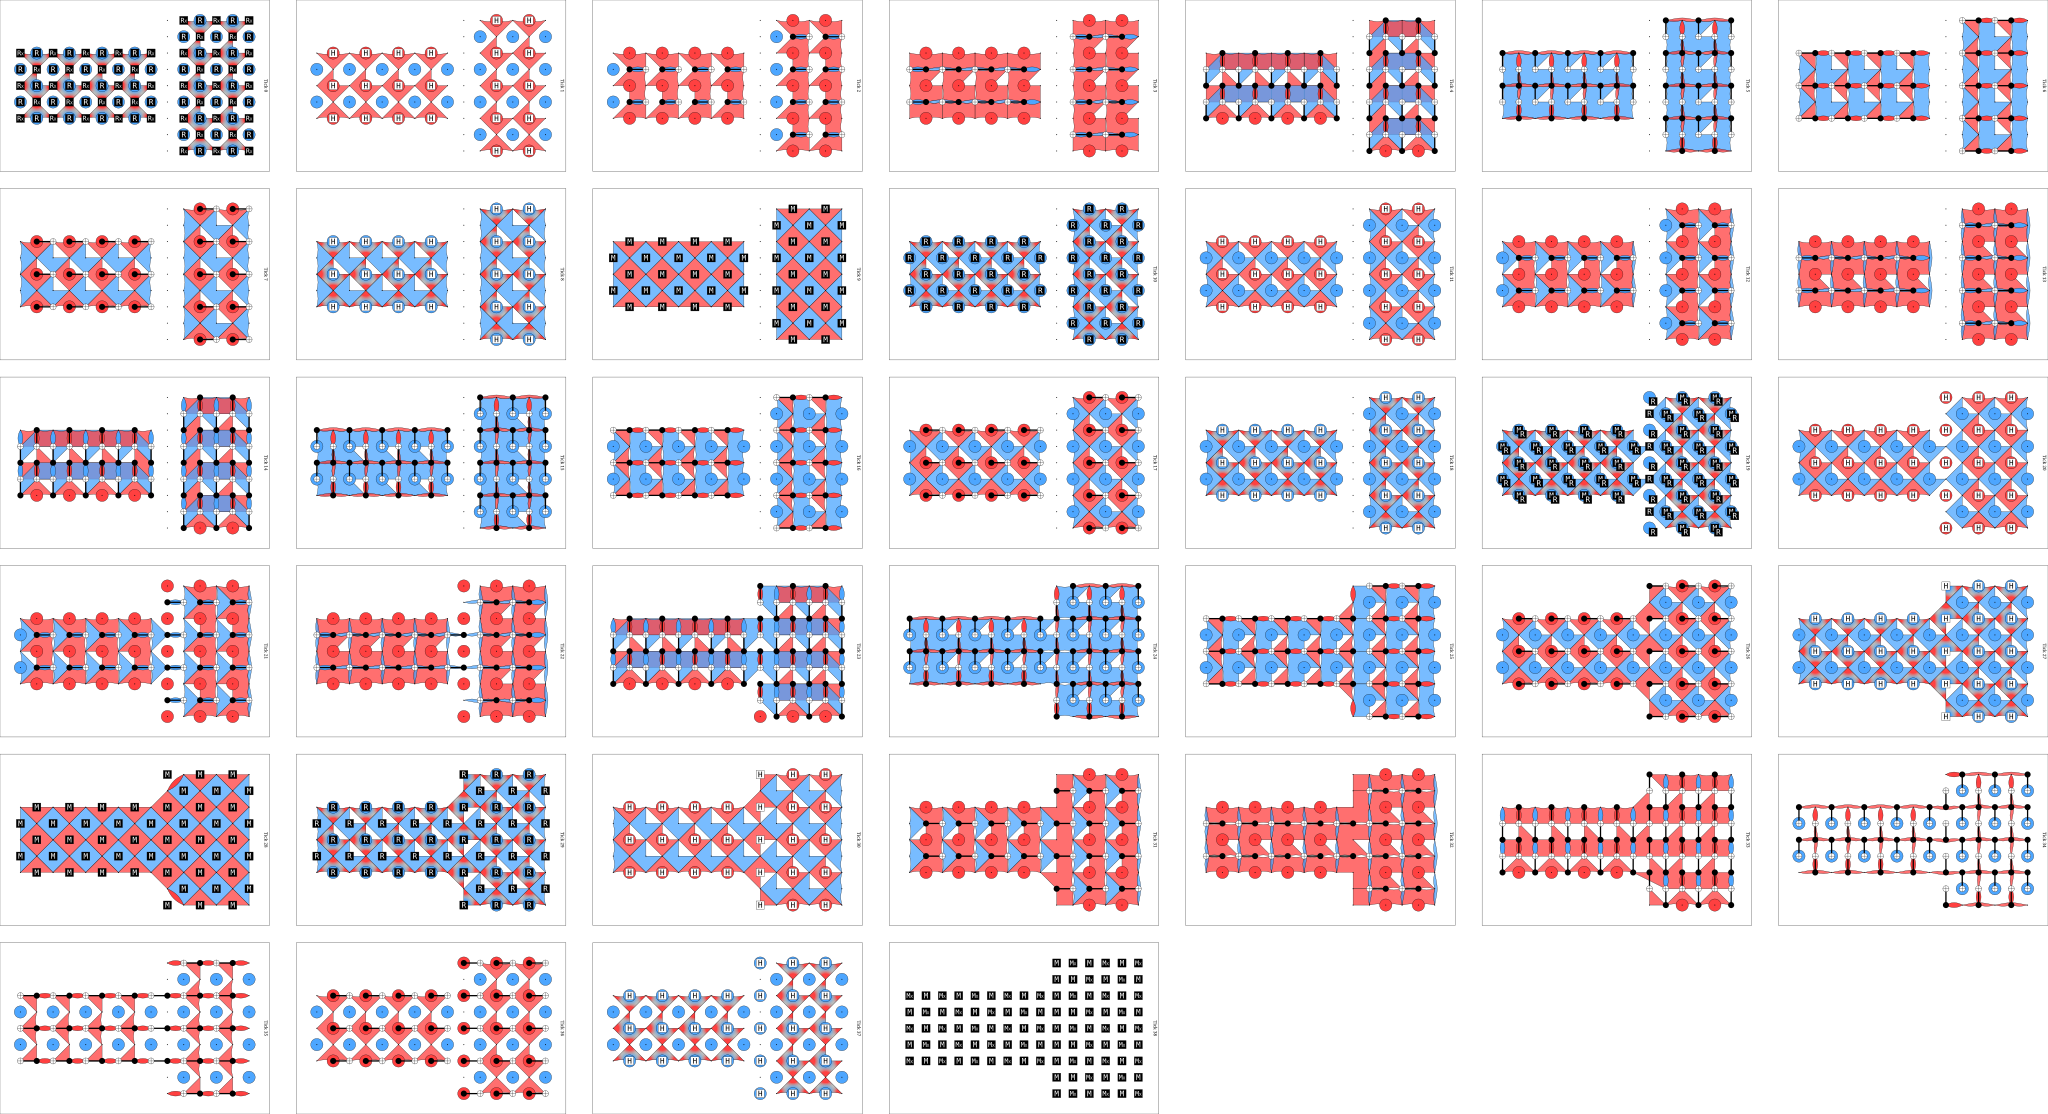

In [10]:
# Example 3: Different patch sizes (rectangular patches)
experiment_rect = TwoPatchLSExperiment(
    patch1_config={"distance_z": 5, "distance_x": 3},
    patch2_config={"distance_z": 3, "distance_x": 5},
    offset=(10, -2), # (10, -2), (10, -0)
    interaction_type="XX",
    initial_state_patch1="X",
    initial_state_patch2="X",
    measure_state_patch1="X",
    measure_state_patch2="X",
    rounds=2
)

circuit_rect = experiment_rect.build()
circuit_rect.diagram("detslice-with-ops-svg")
# circuit_rect.diagram("detslice-with-ops-svg", filter_coords=["L0"]) # "L1"

## Example 4: Logical Error Rate vs $p$

Circuit-level depolarizing noise, `rounds = d`, PyMatching decoder. Below threshold the LER is suppressed with code distance — the unrotated two-patch merge is error-correcting. (Quick demo sweep; full high-statistics version: `benchmarks/logical_ops/` gates `TwoPatchLS_XX` / `TwoPatchLS_ZZ`.)

d=3: 1e-03->3.7e-03  2e-03->1.4e-02  3e-03->3.0e-02  5e-03->8.3e-02  7e-03->1.4e-01  1e-02->2.4e-01
d=5: 1e-03->2.8e-04  2e-03->3.4e-03  3e-03->1.4e-02  5e-03->6.4e-02  7e-03->1.5e-01  1e-02->3.2e-01
d=7: 1e-03->2.5e-05  2e-03->8.2e-04  3e-03->4.7e-03  5e-03->4.0e-02  7e-03->1.5e-01  1e-02->3.8e-01


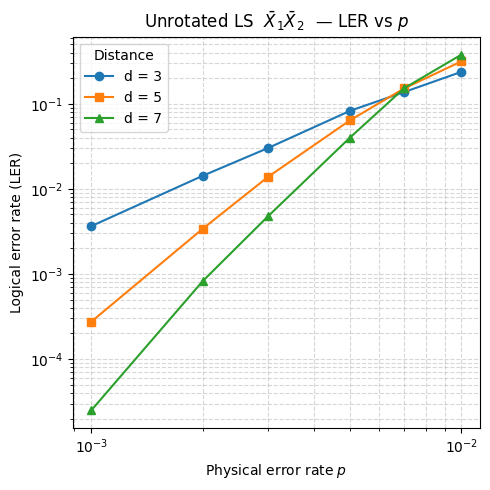

In [11]:
import io, contextlib
import pymatching
import matplotlib.pyplot as plt
from lightstim.noise.config import NoiseConfig

def ler(d, p, max_shots=40000, max_errors=50, batch=20000):
    noise = NoiseConfig(p_meas=p, p_reset=p, p_1q=p, p_2q=p, p_idle=p)
    exp = TwoPatchLSExperiment(
        patch1_config={"distance": d}, patch2_config={"distance": d},
        offset=(4 * d - 2, 0), interaction_type="XX",        # unrotated XX = left-right
        initial_state_patch1="X", initial_state_patch2="Z",
        measure_state_patch1="Z", measure_state_patch2="X",
        rounds=d, noise_params=noise, noise_model="circuit_level",
    )
    with contextlib.redirect_stdout(io.StringIO()):
        circ = exp.build()
    matcher = pymatching.Matching.from_detector_error_model(
        circ.detector_error_model(decompose_errors=True))
    sampler = circ.compile_detector_sampler()
    shots = errors = 0
    while shots < max_shots and errors < max_errors:
        n = min(batch, max_shots - shots)
        dets, obs = sampler.sample(n, separate_observables=True)
        errors += int(np.sum(np.any(matcher.decode_batch(dets) != obs, axis=1)))
        shots += n
    return errors / shots

ps = [1e-3, 2e-3, 3e-3, 5e-3, 7e-3, 1e-2]
plt.figure(figsize=(5, 5))
for d, mk in [(3, "o"), (5, "s"), (7, "^")]:
    ys = [ler(d, p) for p in ps]
    plt.loglog(ps, ys, marker=mk, label=f"d = {d}")
    print(f"d={d}: " + "  ".join(f"{p:.0e}->{y:.1e}" for p, y in zip(ps, ys)))

plt.xlabel("Physical error rate $p$")
plt.ylabel("Logical error rate (LER)")
plt.title(r"Unrotated LS  $\bar X_1 \bar X_2$  — LER vs $p$")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(title="Distance"); plt.tight_layout(); plt.show()

## Why unrotated absorbs the RIGHT logical (compare to `two_patch_LS_rotated.ipynb`)

A ZZ merge measures $\bar Z_1\bar Z_2$, which anti-commutes with $\bar X_1$ — so the protocol must
**absorb $\bar X_1$**. The tracker (Case A in `process_mid_measurement`) absorbs whichever logical's
representative a newly-measured seam/boundary check anti-commutes with — i.e. the logical that
**terminates at the merge boundary** (its open end becomes interior after the merge).

The geometric difference between the two codes is *which* operator terminates at the ZZ-merge boundary:

| | ZZ merge geometry | operator ⊥ to seam (interior-open, absorbed) | matches theory ($\bar X_1$)? |
|---|---|---|---|
| **unrotated** | vertical stack, merge along patch-1's **top** | $\bar X_1$ (vertical, ends at the top boundary) | ✅ yes |
| **rotated**   | side-by-side, merge along patch-1's **right (Z-)boundary** | $\bar Z_2$ (horizontal, ends at the seam) | ❌ no — wrong one |

So in **unrotated** the operator that goes interior-open is $\bar X_1$ = exactly the one to consume.
In **rotated** the merge runs along the *Z*-boundary, so the interior-open operator is $\bar Z_2$ —
which **commutes** with the joint $\bar Z_1\bar Z_2$ and should have *survived*. The mechanism is
identical; only the boundary orientation flips which logical it catches.

pre-merge logicals: ['X_1', 'Z_2']
THEORY: ZZ measures Z1*Z2 -> anti-commutes with X_1 -> should absorb X_1
ACTUAL Case-A absorb: X_1  by p_hat syn=(4.0, 5.0) (Z-type [(4.0, 4.0), (4, 6.0), (3.0, 5.0)])  anti_rows=['X_1']


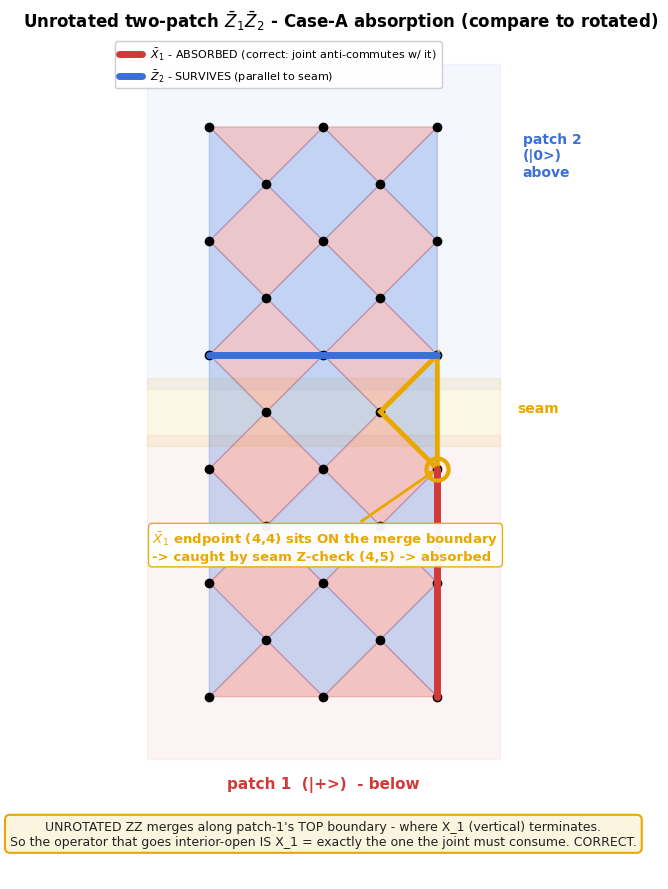

In [12]:
# --- Unrotated ZZ merge: Case-A absorption trace + geometry (compare to rotated) ---
import io, contextlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
import lightstim.protocols.two_patch_ls as _tp
from lightstim.utils.linear_algebra import check_commutativity

# build the ZZ merge with init (X, Z), capturing the merge-step tableau
_cap = {}
_Real = _tp.SyndromeTracker
def _Hook(*a, **k):
    t = _Real(*a, **k)
    _orig = t.process_mid_measurement
    def _w(*aa, **kk):
        if t.logicals.count == 2 and "pre" not in _cap:
            _cap["pre"] = dict(stab=t.stabilizers.matrix.copy(),
                rec=[list(r) for r in t.stabilizers.records], log=t.logicals.matrix.copy(),
                bpp=kk["back_propagated_paulis"].copy(), syn=list(kk["syn_coords"]), n=t.num_qubits)
        return _orig(*aa, **kk)
    t.process_mid_measurement = _w
    return t
_tp.SyndromeTracker = _Hook
_exp = TwoPatchLSExperiment(
    patch1_config={"distance": 3}, patch2_config={"distance": 3},
    offset=(0, 6), interaction_type="ZZ",
    code_patch_class=UnrotatedSurfaceCode, coupler_protocol=UnrotatedTwoPatchCoupler(),
    extraction_block_class=UnrotatedSurfaceCodeExtractionBlock,
    initial_state_patch1="X", initial_state_patch2="Z",
    measure_state_patch1="X", measure_state_patch2="Z",
    rounds=2, rotate_patch1=True)
with contextlib.redirect_stdout(io.StringIO()):
    _exp.build()
_tp.SyndromeTracker = _Real
s = _exp.system; qc = s.qubit_coords; own = s.index_to_owner_map; P = _cap["pre"]; n = P["n"]

# replay the Case-A loop to see which logical is absorbed and by which p_hat
def _lab(row):
    sp = [(own.get(q, "?"), "X" if row[q] and not row[n + q] else ("Z" if row[n + q] else "Y"))
          for q in range(n) if row[q] or row[n + q]]
    typ = "".join(sorted(set(x[1] for x in sp)))
    sc = "".join("1" if "code_1" in o else "2" for o in sorted(set(x[0] for x in sp)))
    return f"{typ}_{sc}"
LOG = {k: _lab(row) for k, row in enumerate(P["log"])}
stab = P["stab"].copy(); rec = P["rec"]
emp = [i for i in range(len(rec)) if rec[i] == []]; oth = [i for i in range(len(rec)) if rec[i] != []]
if emp and oth: stab = stab[emp + oth]
ns = stab.shape[0]; full = np.vstack([stab, P["log"]]).astype(np.int64)
LOGNAME = {ns + k: LOG[k] for k in LOG}; bpp = P["bpp"].astype(np.int64)
print("pre-merge logicals:", [LOG[k] for k in sorted(LOG)])
print("THEORY: ZZ measures Z1*Z2 -> anti-commutes with X_1 -> should absorb X_1")
for i in range(bpp.shape[0]):
    anti = list(np.where(check_commutativity(bpp[i].reshape(1, -1), full)[0])[0])
    if anti:
        piv = anti[0]
        if piv in LOGNAME:
            sp = [qc.get(q) for q in range(n) if bpp[i][q] or bpp[i][n + q]]
            ty = "X" if any(bpp[i][q] for q in range(n)) and not any(bpp[i][n + q] for q in range(n)) else "Z"
            print(f"ACTUAL Case-A absorb: {LOGNAME[piv]}  by p_hat syn={P['syn'][i]} ({ty}-type {sp})  "
                  f"anti_rows={[LOGNAME.get(j, 'stab') for j in anti]}")
        for o in anti[1:]: full[o] = (full[o] + full[piv]) % 2
        full[piv] = bpp[i] % 2

# geometry plot
RED, BLUE, GOLD = "#d23a3a", "#3a6fd8", "#e8a800"
fig, ax = plt.subplots(figsize=(8.5, 9))
ax.add_patch(Rectangle((-1.1, -1.1), 6.2, 5.7, color=RED,  alpha=0.05, zorder=0))
ax.add_patch(Rectangle((-1.1,  5.4), 6.2, 5.7, color=BLUE, alpha=0.05, zorder=0))
ax.add_patch(Rectangle((-1.1,  4.4), 6.2, 1.2, color=GOLD, alpha=0.10, zorder=0))
def _osq(cs):
    cen = np.mean(cs, axis=0); return sorted(cs, key=lambda p: np.arctan2(p[1] - cen[1], p[0] - cen[0]))
for st in s.active_stabilizers:
    cs = [qc[i] for i in st["data_indices"]]; col = RED if st["type"] == "X" else BLUE
    if len(cs) >= 3:
        ax.add_patch(Polygon(_osq(cs), closed=True, facecolor=col, alpha=0.26, edgecolor=col, lw=1.0, zorder=1))
    elif len(cs) == 2:
        (x0, y0), (x1, y1) = cs; mx, my = (x0 + x1) / 2, (y0 + y1) / 2; b = 0.4
        ax.add_patch(Polygon([(x0, y0), (mx + (b if x0 == x1 else 0), my + (0 if x0 == x1 else b)),
                              (x1, y1), (mx - (b if x0 == x1 else 0), my - (0 if x0 == x1 else b))],
                             closed=True, facecolor=col, alpha=0.22, edgecolor=col, lw=0.8, zorder=1))
for (x, y) in [qc[i] for i in s.data_indices]:
    ax.plot(x, y, "o", color="black", ms=6, zorder=5)
for st in s.active_stabilizers:
    if st["syn_coord"] == (4.0, 5.0):
        ax.add_patch(Polygon(_osq([qc[i] for i in st["data_indices"]]), closed=True, fill=False,
                             edgecolor=GOLD, lw=3.5, zorder=6))
ax.plot([4, 4, 4], [0, 2, 4], color=RED, lw=5, zorder=7, solid_capstyle="round",
        label=r"$\bar X_1$ - ABSORBED (correct: joint anti-commutes w/ it)")
ax.plot([0, 2, 4], [6, 6, 6], color=BLUE, lw=5, zorder=7, solid_capstyle="round",
        label=r"$\bar Z_2$ - SURVIVES (parallel to seam)")
ax.plot(4, 4, "o", color=GOLD, ms=16, mfc="none", mew=3, zorder=8)
ax.annotate(r"$\bar X_1$ endpoint (4,4) sits ON the merge boundary" + "\n-> caught by seam Z-check (4,5) -> absorbed",
            xy=(4, 4), xytext=(-1.0, 2.4), fontsize=9.5, color=GOLD, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=GOLD, lw=2), zorder=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=GOLD, alpha=0.95))
ax.text(5.5, 9.5, "patch 2\n(|0>)\nabove", color=BLUE, ha="left", va="center", fontsize=10, fontweight="bold")
ax.text(2.0, -1.6, "patch 1  (|+>)  - below", color=RED, ha="center", fontsize=11, fontweight="bold")
ax.text(5.4, 5.0, "seam", color=GOLD, ha="left", fontsize=10, fontweight="bold")
ax.text(2.0, -2.6, "UNROTATED ZZ merges along patch-1's TOP boundary - where X_1 (vertical) terminates.\n"
        "So the operator that goes interior-open IS X_1 = exactly the one the joint must consume. CORRECT.",
        ha="center", fontsize=9, color="#222", bbox=dict(boxstyle="round,pad=0.4", fc="#fbf5e0", ec=GOLD, lw=1.5))
ax.set_xlim(-1.6, 6.2); ax.set_ylim(-3.2, 11.6); ax.set_aspect("equal"); ax.axis("off")
ax.set_title(r"Unrotated two-patch $\bar Z_1\bar Z_2$ - Case-A absorption (compare to rotated)",
             fontsize=12, fontweight="bold")
ax.legend(loc="upper left", fontsize=8, framealpha=0.96, bbox_to_anchor=(-0.02, 1.0))
plt.tight_layout(); plt.show()